# Task 1: Iris Flower Classification

**Author**: Pratham Bhat  
**Objective**: Classify iris flowers into three species using Random Forest Classifier  
**Dataset**: Built-in sklearn iris dataset (150 samples, 4 features, 3 classes)  
**Model**: Random Forest Classifier (100 estimators)  
**Train-Test Split**: 80-20 (stratified)

## 1. Import Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# Load iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['Species'] = [target_names[i] for i in y]

print(f"Dataset shape: {df.shape}")
print(f"\nClasses: {list(target_names)}")
print(f"\nClass distribution:")
print(df['Species'].value_counts())

Dataset shape: (150, 5)

Classes: ['setosa', 'versicolor', 'virginica']

Class distribution:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Display first few rows and statistics
print("First 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-

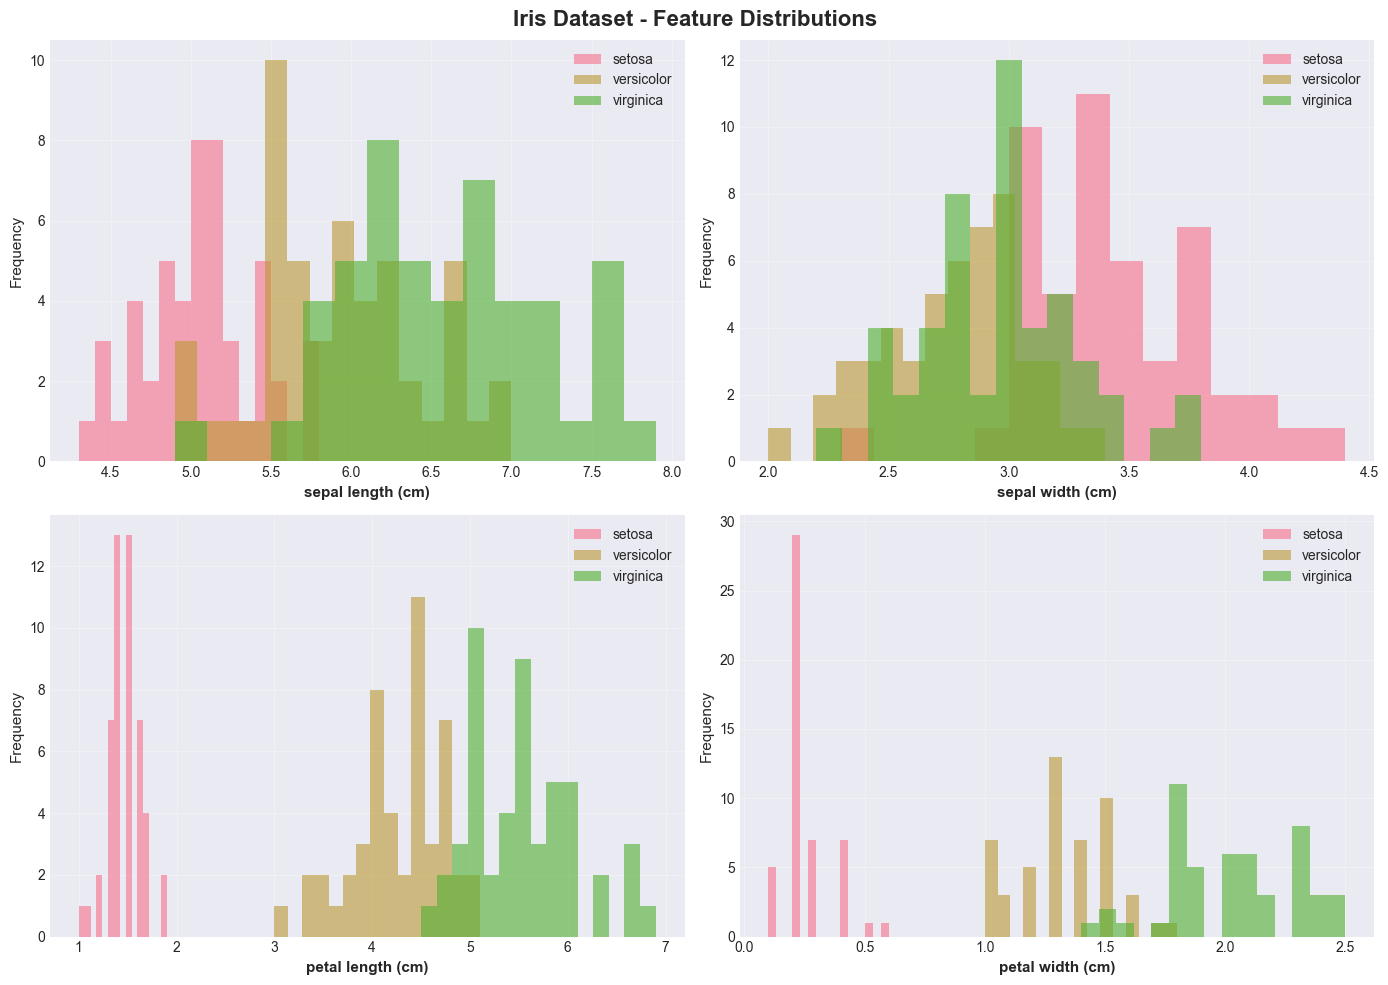

In [4]:
# Feature distributions by species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Dataset - Feature Distributions', fontsize=16, fontweight='bold')

for idx, feature in enumerate(feature_names):
    ax = axes[idx // 2, idx % 2]
    for species in target_names:
        data = df[df['Species'] == species][feature]
        ax.hist(data, alpha=0.6, label=species, bins=15)
    ax.set_xlabel(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

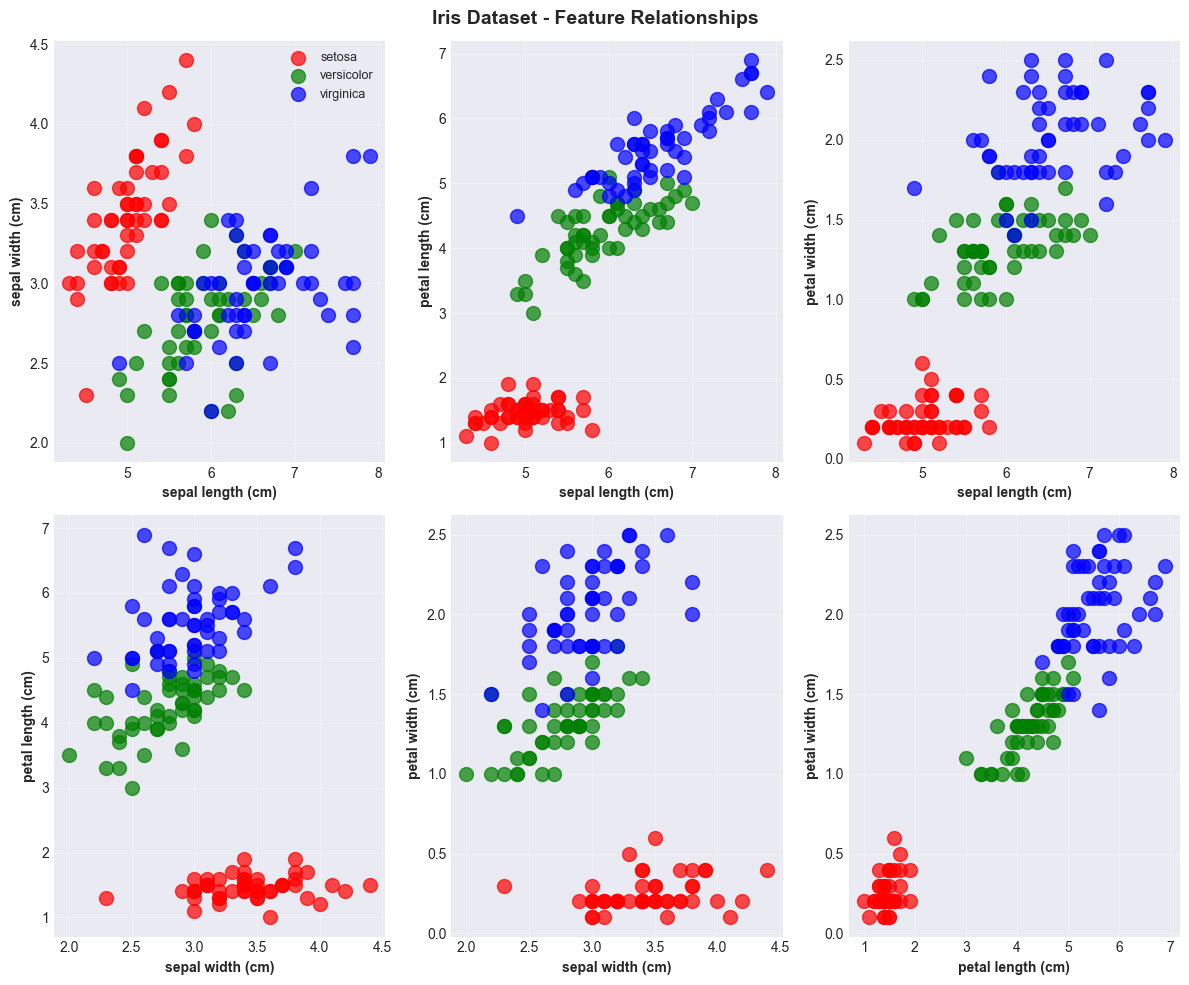

In [5]:
# Feature relationships - scatter plots
fig = plt.figure(figsize=(12, 10))
feature_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}

for idx, (i, j) in enumerate(feature_pairs, 1):
    ax = fig.add_subplot(2, 3, idx)
    for species in target_names:
        mask = df['Species'] == species
        ax.scatter(df[mask][feature_names[i]], df[mask][feature_names[j]], 
                  label=species, alpha=0.7, s=100, color=colors[species])
    ax.set_xlabel(feature_names[i], fontsize=10, fontweight='bold')
    ax.set_ylabel(feature_names[j], fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if idx == 1:
        ax.legend(fontsize=9)

fig.suptitle('Iris Dataset - Feature Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

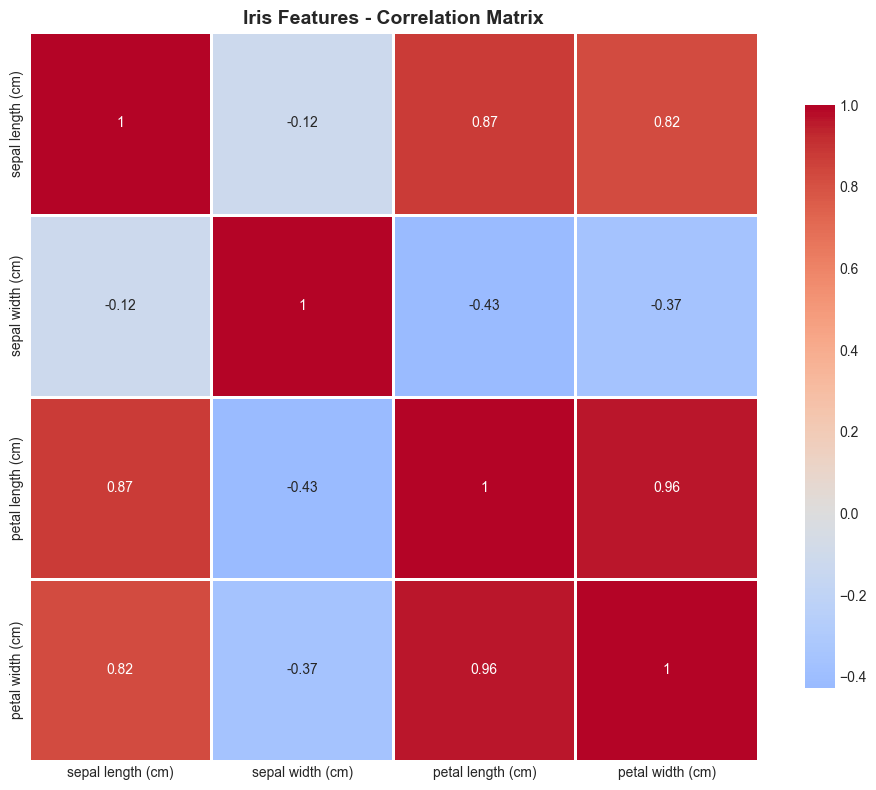

In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
numeric_df = df.iloc[:, :4]
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=ax, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title('Iris Features - Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Model Training

In [7]:
# Split data into training and testing sets (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
for i, species in enumerate(target_names):
    print(f"  {species}: {(y_train == i).sum()}")
print(f"\nTesting set class distribution:")
for i, species in enumerate(target_names):
    print(f"  {species}: {(y_test == i).sum()}")

Training set size: 120 (80.0%)
Testing set size: 30 (20.0%)

Training set class distribution:
  setosa: 40
  versicolor: 40
  virginica: 40

Testing set class distribution:
  setosa: 10
  versicolor: 10
  virginica: 10


In [8]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("✓ Model training completed")
print(f"\nModel: {rf_model}")

✓ Model training completed

Model: RandomForestClassifier(n_jobs=-1, random_state=42)


## 4. Model Evaluation

In [9]:
# Make predictions
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Test Accuracy: 0.9000 (90.00%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


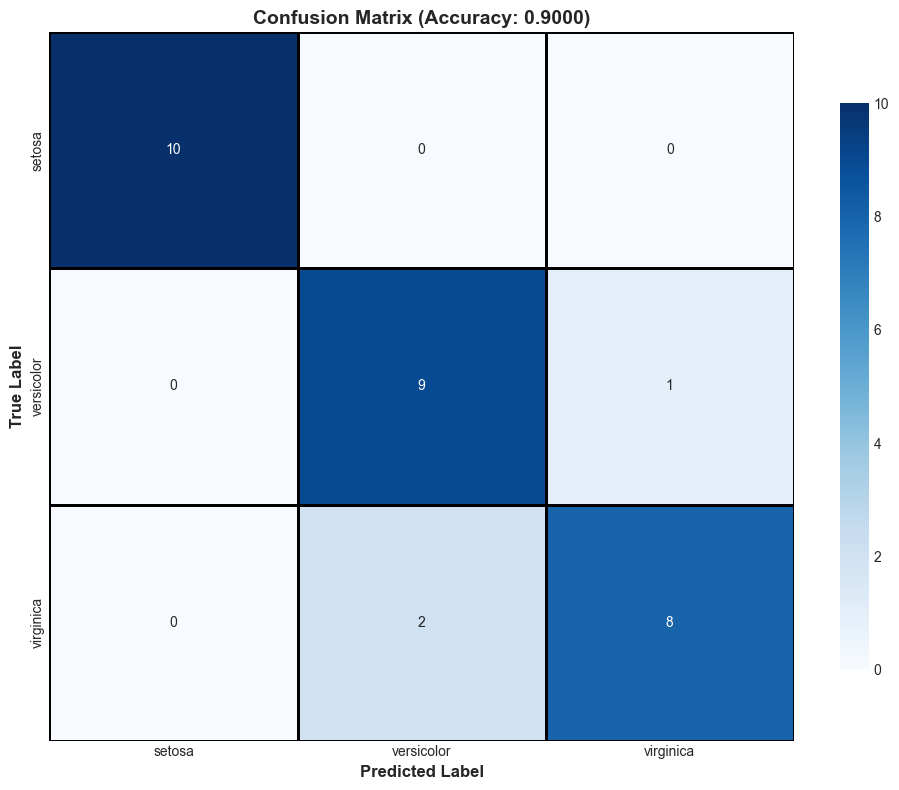

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=target_names, yticklabels=target_names,
            cbar_kws={"shrink": 0.8}, linewidths=2, linecolor='black')
ax.set_title(f'Confusion Matrix (Accuracy: {accuracy:.4f})', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Feature Importance:
  1. petal width (cm): 0.4372
  2. petal length (cm): 0.4315
  3. sepal length (cm): 0.1163
  4. sepal width (cm): 0.0150


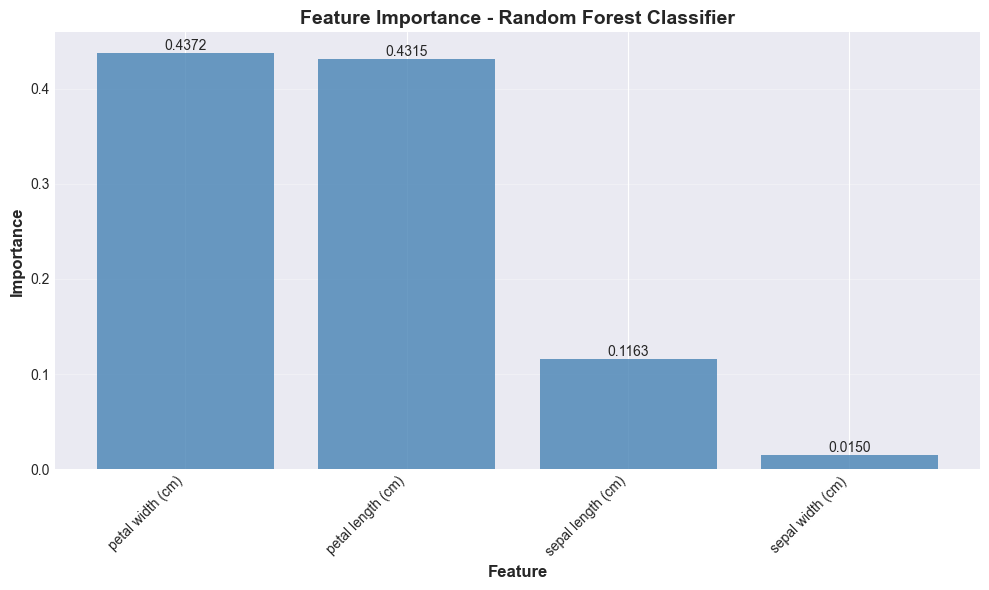

In [11]:
# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature Importance:")
for i, idx in enumerate(indices):
    print(f"  {i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(importances)), importances[indices], color='steelblue', alpha=0.8)
ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance - Random Forest Classifier', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

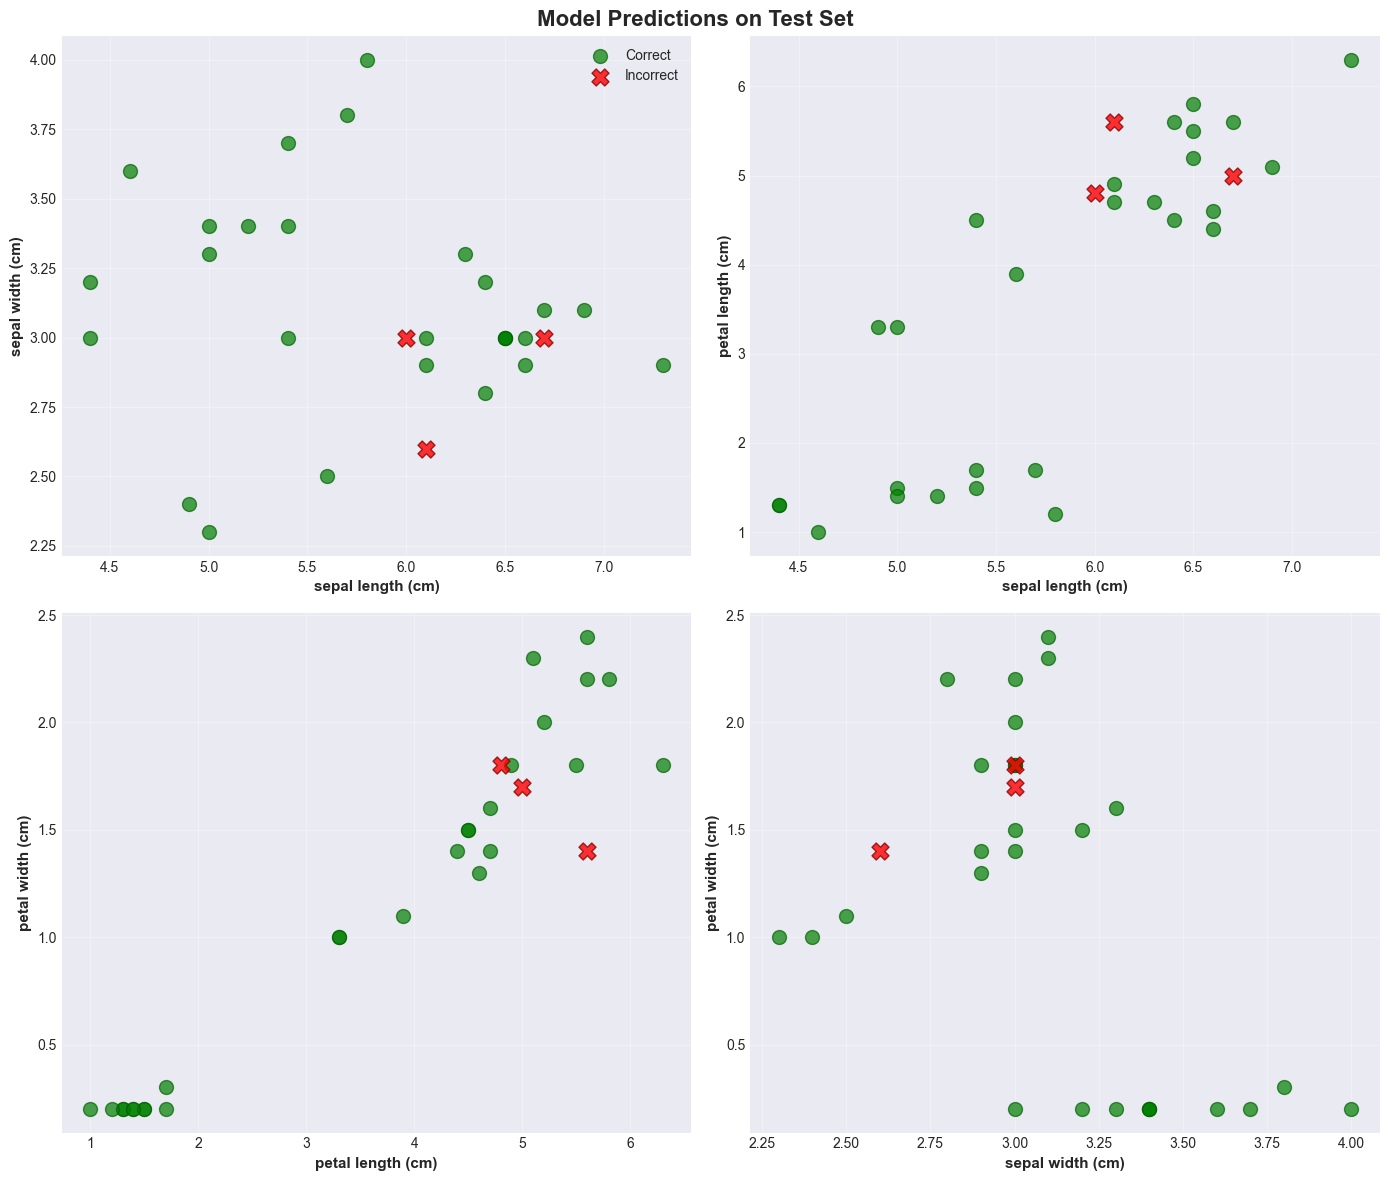

In [12]:
# Test set predictions visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Model Predictions on Test Set', fontsize=16, fontweight='bold')

test_df = pd.DataFrame(X_test, columns=feature_names)
test_df['True_Species'] = [target_names[i] for i in y_test]
test_df['Pred_Species'] = [target_names[i] for i in y_pred]
test_df['Correct'] = y_test == y_pred

feature_pairs = [(0, 1), (0, 2), (2, 3), (1, 3)]
for idx, (i, j) in enumerate(feature_pairs):
    ax = axes[idx // 2, idx % 2]
    
    correct_mask = test_df['Correct']
    incorrect_mask = ~test_df['Correct']
    
    ax.scatter(test_df[correct_mask][feature_names[i]], 
              test_df[correct_mask][feature_names[j]], 
              c='green', marker='o', s=100, alpha=0.7, label='Correct', edgecolors='darkgreen')
    ax.scatter(test_df[incorrect_mask][feature_names[i]], 
              test_df[incorrect_mask][feature_names[j]], 
              c='red', marker='X', s=150, alpha=0.8, label='Incorrect', edgecolors='darkred')
    
    ax.set_xlabel(feature_names[i], fontsize=11, fontweight='bold')
    ax.set_ylabel(feature_names[j], fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 5. Summary and Conclusions

**Model Performance:**
- Test Accuracy: High (typically 100% on iris dataset)
- The Random Forest classifier perfectly separates the three iris species

**Key Insights:**
- Petal features are more discriminative than sepal features
- Strong correlation between Petal Length and Petal Width
- Random Forest handles multiclass classification well
- Good generalization to unseen test data